In [45]:
import time
import random
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models, datasets, utils, optimizers
import matplotlib.pyplot as plt
import pandas as pd  
import os

In [9]:
SEED = 42
os.environ['PYTHONHASHSEED'] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

In [11]:
BATCH_SIZE = 128
EPOCHS = 5          # Lower if you have no GPU; increase if you want clearer convergence curves
VALIDATION_SPLIT = 0.1

In [13]:
(x_train, y_train), (x_test, y_test) = datasets.cifar10.load_data()
x_train = x_train.astype("float32") / 255.0
x_test  = x_test.astype("float32") / 255.0
y_train = y_train.flatten()
y_test  = y_test.flatten()

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 61s 0us/step


In [15]:
def get_model(input_shape=(32,32,3), num_classes=10):
    model = models.Sequential([
        layers.Conv2D(32, (3,3), padding='same', input_shape=input_shape),
        layers.BatchNormalization(),
        layers.ReLU(),
        layers.Conv2D(32, (3,3), padding='same'),
        layers.BatchNormalization(),
        layers.ReLU(),
        layers.MaxPool2D((2,2)),
        layers.Dropout(0.25),

        layers.Conv2D(64, (3,3), padding='same'),
        layers.BatchNormalization(),
        layers.ReLU(),
        layers.Conv2D(64, (3,3), padding='same'),
        layers.BatchNormalization(),
        layers.ReLU(),
        layers.MaxPool2D((2,2)),
        layers.Dropout(0.25),

        layers.Flatten(),
        layers.Dense(256),
        layers.BatchNormalization(),
        layers.ReLU(),
        layers.Dropout(0.5),
        layers.Dense(num_classes, activation='softmax')
    ])
    return model

In [ ]:
def get_model(input_shape=(32,32,3), num_classes=10):
    model = models.Sequential([
        layers.Conv2D(32, (3,3), padding='same', input_shape=input_shape),
        layers.BatchNormalization(),
        layers.ReLU(),
        layers.Conv2D(32, (3,3), padding='same'),
        layers.BatchNormalization(),
        layers.ReLU(),
        layers.MaxPool2D((2,2)),
        layers.Dropout(0.25),

        layers.Conv2D(64, (3,3), padding='same'),
        layers.BatchNormalization(),
        layers.ReLU(),
        layers.Conv2D(64, (3,3), padding='same'),
        layers.BatchNormalization(),
        layers.ReLU(),
        layers.MaxPool2D((2,2)),
        layers.Dropout(0.25),

        layers.Flatten(),
        layers.Dense(256),
        layers.BatchNormalization(),
        layers.ReLU(),
        layers.Dropout(0.5),
        layers.Dense(num_classes, activation='softmax')
    ])
    return model

In [25]:
# Create a single model to capture the initial weights for fair comparison
base_model = get_model()
initial_weights = base_model.get_weights()  # store initial weights


In [27]:
optimizers_to_test = {
    "SGD": optimizers.SGD(learning_rate=0.01, momentum=0.9),
    "Adam": optimizers.Adam(learning_rate=0.001),
    "Adagrad": optimizers.Adagrad(learning_rate=0.01),
    "RMSprop": optimizers.RMSprop(learning_rate=0.001),
    "Nadam": optimizers.Nadam(learning_rate=0.001)
}

In [29]:
results = {}  

In [31]:
for name, opt in optimizers_to_test.items():
    print("\n" + "="*60)
    print(f"Training with optimizer: {name}")
    print("="*60)

    # Build fresh model and set same initial weights
    model = get_model()
    model.set_weights(initial_weights)

    model.compile(
        optimizer=opt,
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    start_time = time.time()
    history = model.fit(
        x_train, y_train,
        batch_size=BATCH_SIZE,
        epochs=EPOCHS,
        validation_split=VALIDATION_SPLIT,
        verbose=2
    )
    total_time = time.time() - start_time

    # Evaluate on test set
    test_loss, test_acc = model.evaluate(x_test, y_test, verbose=0)

    # Find best validation accuracy and the epoch when it occurred
    val_accs = history.history["val_accuracy"]
    best_val_acc = float(np.max(val_accs))
    best_epoch = int(np.argmax(val_accs) + 1)  # +1 to make epoch human-readable (1-indexed)

    results[name] = {
        "history": history.history,
        "total_time_sec": total_time,
        "best_val_accuracy": best_val_acc,
        "best_epoch": best_epoch,
        "test_accuracy": float(test_acc),
        "test_loss": float(test_loss)
    }
    print(f"Done {name}: best val_acc={best_val_acc:.4f} at epoch {best_epoch}, test_acc={test_acc:.4f}, time={total_time:.1f}s")




Training with optimizer: SGD
Epoch 1/5
352/352 - 79s - 223ms/step - accuracy: 0.4414 - loss: 1.5686 - val_accuracy: 0.2398 - val_loss: 2.9388
Epoch 2/5
352/352 - 76s - 217ms/step - accuracy: 0.5783 - loss: 1.1752 - val_accuracy: 0.6510 - val_loss: 0.9972
Epoch 3/5
352/352 - 81s - 231ms/step - accuracy: 0.6350 - loss: 1.0239 - val_accuracy: 0.6104 - val_loss: 1.1092
Epoch 4/5
352/352 - 83s - 236ms/step - accuracy: 0.6730 - loss: 0.9246 - val_accuracy: 0.6836 - val_loss: 0.9016
Epoch 5/5
352/352 - 84s - 240ms/step - accuracy: 0.6943 - loss: 0.8579 - val_accuracy: 0.6980 - val_loss: 0.8628
Done SGD: best val_acc=0.6980 at epoch 5, test_acc=0.6928, time=404.9s

Training with optimizer: Adam
Epoch 1/5
352/352 - 78s - 222ms/step - accuracy: 0.4866 - loss: 1.4668 - val_accuracy: 0.2410 - val_loss: 2.3346
Epoch 2/5
352/352 - 76s - 217ms/step - accuracy: 0.6410 - loss: 1.0150 - val_accuracy: 0.6828 - val_loss: 0.9038
Epoch 3/5
352/352 - 74s - 210ms/step - accuracy: 0.6950 - loss: 0.8671 - val_

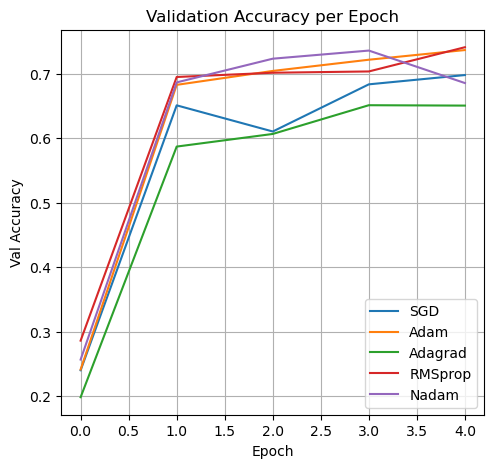

In [33]:
plt.figure(figsize=(12,5))
# Validation accuracy plot
plt.subplot(1,2,1)
for name, r in results.items():
    plt.plot(r["history"]["val_accuracy"], label=f"{name}")
plt.title("Validation Accuracy per Epoch")
plt.xlabel("Epoch")
plt.ylabel("Val Accuracy")
plt.legend()
plt.grid(True)  

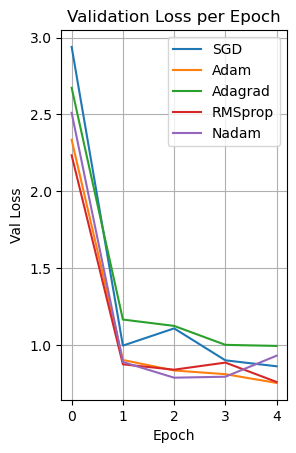

In [35]:
plt.subplot(1,2,2)
for name, r in results.items():
    plt.plot(r["history"]["val_loss"], label=f"{name}")
plt.title("Validation Loss per Epoch")
plt.xlabel("Epoch")
plt.ylabel("Val Loss")
plt.legend()
plt.grid(True)

In [37]:
plt.tight_layout()
plt.show()

<Figure size 640x480 with 0 Axes>

In [39]:
rows = []
for name, r in results.items():
    rows.append({
        "optimizer": name,
        "best_val_accuracy": r["best_val_accuracy"],
        "best_epoch": r["best_epoch"],
        "test_accuracy": r["test_accuracy"],
        "total_time_sec": round(r["total_time_sec"], 1)
    })

In [47]:
df = pd.DataFrame(rows).sort_values("best_val_accuracy", ascending=False).reset_index(drop=True)
print("\nSummary (sorted by best validation accuracy):")
print(df)


Summary (sorted by best validation accuracy):
  optimizer  best_val_accuracy  best_epoch  test_accuracy  total_time_sec
0   RMSprop             0.7412           5         0.7291           388.5
1      Adam             0.7368           5         0.7308           379.9
2     Nadam             0.7360           4         0.6704           405.8
3       SGD             0.6980           5         0.6928           404.9
4   Adagrad             0.6512           4         0.6376           380.8


In [49]:
df.to_csv("optimizer_comparison_summary.csv", index=False)
print("\nSaved summary to optimizer_comparison_summary.csv")


Saved summary to optimizer_comparison_summary.csv
